In [1]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("../data/raw/T1.csv")

In [4]:
df.columns

Index(['Date/Time', 'LV ActivePower (kW)', 'Wind Speed (m/s)',
       'Theoretical_Power_Curve (KWh)', 'Wind Direction (°)'],
      dtype='object')

In [5]:
df.rename(columns={"LV ActivePower (kW)": "actual_power_kW", "Wind Speed (m/s)": "wind_speed_m/s",
                   "Theoretical_Power_Curve (KWh)":"theoretical_power_kW","Wind Direction (°)":"wind_direction_deg",
                   "Date/Time":"date_time"}, inplace=True)

In [6]:
df['date_time']=pd.to_datetime(df['date_time'], format='%d %m %Y %H:%M')

In [7]:
print("Missing data")
print(df.isnull().sum())

Missing data
date_time               0
actual_power_kW         0
wind_speed_m/s          0
theoretical_power_kW    0
wind_direction_deg      0
dtype: int64


In [8]:
df.describe()

,date_time,actual_power_kW,wind_speed_m/s,theoretical_power_kW,wind_direction_deg
count,50530,50530.000000,50530.000000,50530.000000,50530.000000
mean,2018-07-01 20:01:30.065307648,1307.684332,7.557952,1492.175463,123.687559
min,2018-01-01 00:00:00,-2.471405,0.000000,0.000000,0.000000
25%,2018-04-03 05:22:30,50.677890,4.201395,161.328167,49.315437
50%,2018-06-30 16:15:00,825.838074,7.104594,1063.776283,73.712978
75%,2018-09-26 18:57:30,2482.507568,10.300020,2964.972462,201.696720
max,2018-12-31 23:50:00,3618.732910,25.206011,3600.000000,359.997589
std,NaN,1312.459242,4.227166,1368.018238,93.443736


In [9]:
print("Shape of data ",df.shape)
print("Range of dates ",min(df['date_time'])," - ",max(df['date_time']))
print("Categorical : ", df.select_dtypes(exclude=[np.number]).columns.tolist())
print("Numerical : ", df.select_dtypes(include=[np.number]).columns.tolist())

Shape of data  (50530, 5)
Range of dates  2018-01-01 00:00:00  -  2018-12-31 23:50:00
Categorical :  ['date_time']
Numerical :  ['actual_power_kW', 'wind_speed_m/s', 'theoretical_power_kW', 'wind_direction_deg']


**Problem Statement**
Analyse data from a wind turbine collected at frequency of 10 minutes to understand
- if the actual power is as per the manufacturers theoretical power curve
- identify if wind direction and season have impact on performance 

In [12]:
df['month']= df['date_time'].dt.month
df['year']= df['date_time'].dt.year
df['hour']= df['date_time'].dt.hour

In [13]:
# power delta
df['power_delta']=df['theoretical_power_kW']-df['actual_power_kW']
df['eff']=df['actual_power_kW']/df['theoretical_power_kW']

In [14]:
season_mapping = {
    12: 'Winter', 1: 'Winter', 2: 'Winter',
    3: 'Spring', 4: 'Spring', 5: 'Spring',
    6: 'Summer', 7: 'Summer', 8: 'Summer',
    9: 'Autumn', 10: 'Autumn', 11: 'Autumn'
}

df['season']=df['month'].map(season_mapping)


In [15]:
def direction_map(deg):
    if deg<22.5 or deg>=337.5:
        return "N"
    elif deg<67.5:
        return "NE"
    elif deg<112.5:
        return "E"
    elif deg<157.5:
        return "SE"
    elif deg<202.5:
        return "S"
    elif deg<247.5:
        return "SW"
    elif deg<292.5:
        return "W"
    else:
        return "NW"

df['wind_dir']= df['wind_direction_deg'].apply(direction_map)

In [67]:
df[df['theoretical_power_kW']==0].describe()

,date_time,actual_power_kW,wind_speed_m/s,theoretical_power_kW,wind_direction_deg,month,year,hour,power_delta,eff
count,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
mean,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
max,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Dropping rows with theoretical power = 0 is this is when the turbine is not running

In [17]:
print("Rows with theoretical power = 0 : ",len(df[df['theoretical_power_kW']==0]))
df=df[df['theoretical_power_kW']>0]

Rows with theoretical power = 0 :  7749


In [18]:
threshold=df['eff'].quantile(0.25)
print("Threshold for efficiency (mean - std_dev) : ",threshold)

Threshold for efficiency (mean - std_dev) :  0.7934635548411231


In [19]:
df['performance_flag']= df['eff'].apply(lambda x : 'Normal' if x>= threshold else 'Underperforming')

In [20]:
print("Final Dataset")
print("Shape of data ",df.shape)
print("Range of dates ",min(df['date_time'])," - ",max(df['date_time']))
print("Categorical : ", df.select_dtypes(exclude=[np.number]).columns.tolist())
print("Numerical : ", df.select_dtypes(include=[np.number]).columns.tolist())

Final Dataset
Shape of data  (42781, 13)
Range of dates  2018-01-01 00:00:00  -  2018-12-31 23:50:00
Categorical :  ['date_time', 'season', 'wind_dir', 'performance_flag']
Numerical :  ['actual_power_kW', 'wind_speed_m/s', 'theoretical_power_kW', 'wind_direction_deg', 'month', 'year', 'hour', 'power_delta', 'eff']


In [21]:
df.describe()

,date_time,actual_power_kW,wind_speed_m/s,theoretical_power_kW,wind_direction_deg,month,year,hour,power_delta,eff
count,42781,42781.000000,42781.000000,42781.000000,42781.000000,42781.00000,42781.0,42781.000000,42781.000000,42781.000000
mean,2018-07-04 00:58:10.226969856,1544.460666,8.568725,1762.455907,115.751140,6.57806,2018.0,11.611510,217.995241,0.811192
min,2018-01-01 00:00:00,-2.471405,3.000684,16.021926,0.000000,1.00000,2018.0,0.000000,-598.741011,-0.132658
25%,2018-03-31 06:00:00,342.748413,5.685735,524.051048,48.071918,3.00000,2018.0,5.000000,23.337891,0.793464
50%,2018-07-05 20:00:00,1212.615967,7.930983,1490.724651,70.260094,7.00000,2018.0,12.000000,96.618789,0.887501
75%,2018-10-05 04:50:00,2778.695068,10.905660,3238.106444,197.472702,10.00000,2018.0,18.000000,231.583868,0.972305
max,2018-12-31 23:50:00,3618.732910,25.206011,3600.000000,359.997589,12.00000,2018.0,23.000000,3600.000000,6.295317
std,NaN,1291.888781,3.789343,1316.851085,87.604681,3.44585,0.0,6.966569,456.882801,0.310700


In [24]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


Duplicate record analysis revealed no duplicate observations. Therefore, no duplicate removal was required.

 # 3. Descriptive Statistics

Descriptive statistics summarize the central tendency and variability of the wind turbine performance variables.

The analysis includes:

- Mean
- Median
- Mode
- Variance
- Standard Deviation
- Range
- Interquartile Range (IQR)

In [34]:
analysis_cols = [
    'actual_power_kW',
    'wind_speed_m/s',
    'theoretical_power_kW',
    'wind_direction_deg',
    'power_delta',
    'eff'
]

In [36]:
#Mean
mean_values = df[analysis_cols].mean()

print("Mean Values")
print(mean_values)

Mean Values
actual_power_kW         1544.460666
wind_speed_m/s             8.568725
theoretical_power_kW    1762.455907
wind_direction_deg       115.751140
power_delta              217.995241
eff                        0.811192
dtype: float64


In [37]:
#Median
median_values = df[analysis_cols].median()

print("Median Values")
print(median_values)

Median Values
actual_power_kW         1212.615967
wind_speed_m/s             7.930983
theoretical_power_kW    1490.724651
wind_direction_deg        70.260094
power_delta               96.618789
eff                        0.887501
dtype: float64


In [38]:
#Mode
mode_values = df[analysis_cols].mode().iloc[0]

print("Mode Values")
print(mode_values)

Mode Values
actual_power_kW            0.000000
wind_speed_m/s             6.112818
theoretical_power_kW    3600.000000
wind_direction_deg         0.000000
power_delta             3600.000000
eff                        0.000000
Name: 0, dtype: float64


In [39]:
#Variance
variance_values = df[analysis_cols].var()

print("Variance")
print(variance_values)

Variance
actual_power_kW         1.668977e+06
wind_speed_m/s          1.435912e+01
theoretical_power_kW    1.734097e+06
wind_direction_deg      7.674580e+03
power_delta             2.087419e+05
eff                     9.653445e-02
dtype: float64


In [40]:
#Standard Deviation
std_values = df[analysis_cols].std()

print("Standard Deviation")
print(std_values)

Standard Deviation
actual_power_kW         1291.888781
wind_speed_m/s             3.789343
theoretical_power_kW    1316.851085
wind_direction_deg        87.604681
power_delta              456.882801
eff                        0.310700
dtype: float64


In [41]:
#Range
range_values = (
    df[analysis_cols].max()
    -
    df[analysis_cols].min()
)

print("Range")
print(range_values)

Range
actual_power_kW         3621.204315
wind_speed_m/s            22.205327
theoretical_power_kW    3583.978074
wind_direction_deg       359.997589
power_delta             4198.741011
eff                        6.427974
dtype: float64


In [42]:
#Interquartile Range (IQR)
Q1 = df[analysis_cols].quantile(0.25)

Q3 = df[analysis_cols].quantile(0.75)

IQR = Q3 - Q1

print("Interquartile Range (IQR)")
print(IQR)

Interquartile Range (IQR)
actual_power_kW         2435.946655
wind_speed_m/s             5.219924
theoretical_power_kW    2714.055396
wind_direction_deg       149.400784
power_delta              208.245978
eff                        0.178841
dtype: float64


In [43]:
# Combined Statistics Table
descriptive_stats = pd.DataFrame({
    'Mean': df[analysis_cols].mean(),
    'Median': df[analysis_cols].median(),
    'Mode': df[analysis_cols].mode().iloc[0],
    'Variance': df[analysis_cols].var(),
    'Std Dev': df[analysis_cols].std(),
    'Minimum': df[analysis_cols].min(),
    'Maximum': df[analysis_cols].max(),
    'Range': df[analysis_cols].max() - df[analysis_cols].min(),
    'IQR': (
        df[analysis_cols].quantile(0.75)
        -
        df[analysis_cols].quantile(0.25)
    )
})

descriptive_stats.round(4)

,Mean,Median,Mode,Variance,Std Dev,Minimum,Maximum,Range,IQR
actual_power_kW,1544.4607,1212.6160,0.0000,1.668977e+06,1291.8888,-2.4714,3618.7329,3621.2043,2435.9467
wind_speed_m/s,8.5687,7.9310,6.1128,1.435910e+01,3.7893,3.0007,25.2060,22.2053,5.2199
theoretical_power_kW,1762.4559,1490.7247,3600.0000,1.734097e+06,1316.8511,16.0219,3600.0000,3583.9781,2714.0554
wind_direction_deg,115.7511,70.2601,0.0000,7.674580e+03,87.6047,0.0000,359.9976,359.9976,149.4008
power_delta,217.9952,96.6188,3600.0000,2.087419e+05,456.8828,-598.7410,3600.0000,4198.7410,208.2460
eff,0.8112,0.8875,0.0000,9.650000e-02,0.3107,-0.1327,6.2953,6.4280,0.1788


In [44]:
descriptive_stats.to_csv(
    "../outputs/tables/descriptive_statistics.csv"
)

print("Descriptive statistics saved successfully.")

Descriptive statistics saved successfully.


### Key Observations

1. Actual power output shows substantial variability, indicating changing wind conditions.

2. Wind speed exhibits moderate dispersion around its average value.

3. Theoretical power output is generally higher than actual output, suggesting performance losses under certain operating conditions.

4. Efficiency values indicate that turbine performance varies across observations.

5. Large ranges and IQR values suggest significant fluctuations in turbine operating conditions.

# 4. Outlier Detection

Outliers are observations that differ significantly from the majority of the data.

In wind turbine data, outliers may occur due to:

- Sensor malfunction
- Extreme weather conditions
- Turbine faults
- Data recording errors

The Interquartile Range (IQR) method and Boxplot Analysis are used to identify outliers.

# Boxplot Analysis

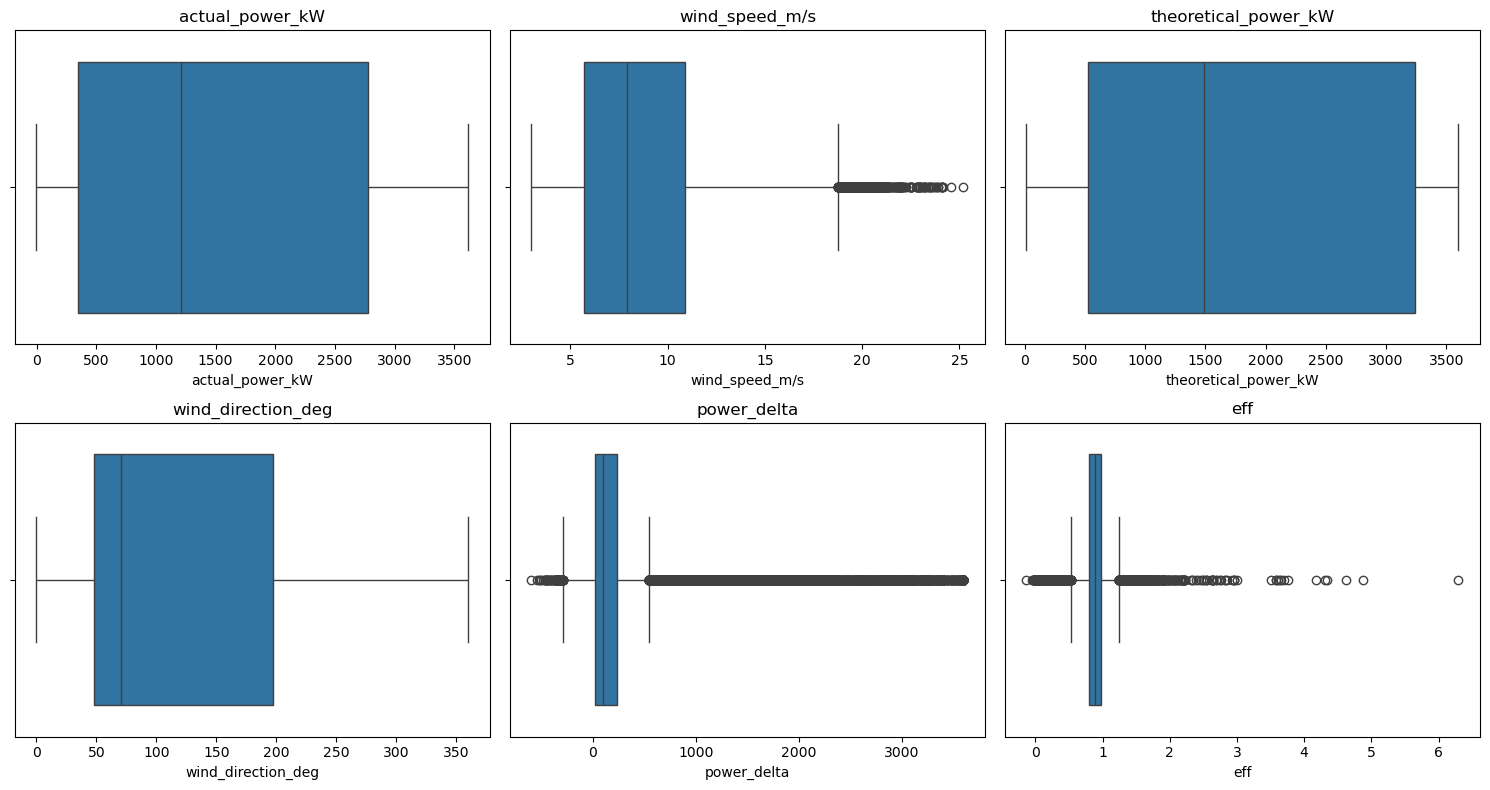

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15,8))

for i, col in enumerate(analysis_cols, 1):
    plt.subplot(2,3,i)
    sns.boxplot(x=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [46]:
#IQR Method
def detect_outliers_iqr(data, column):

    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = data[
        (data[column] < lower_bound)
        |
        (data[column] > upper_bound)
    ]

    return len(outliers), lower_bound, upper_bound

In [47]:
#Count Outliers
outlier_summary = []

for col in analysis_cols:

    count, lower, upper = detect_outliers_iqr(df, col)

    outlier_summary.append([
        col,
        count,
        lower,
        upper
    ])

outlier_df = pd.DataFrame(
    outlier_summary,
    columns=[
        'Variable',
        'Outlier Count',
        'Lower Bound',
        'Upper Bound'
    ]
)

outlier_df

,Variable,Outlier Count,Lower Bound,Upper Bound
0,actual_power_kW,0,-3311.171570,6432.615051
1,wind_speed_m/s,673,-2.144151,18.735546
2,theoretical_power_kW,0,-3547.032045,7309.189537
3,wind_direction_deg,0,-176.029257,421.573877
4,power_delta,3220,-289.031076,543.952835
5,eff,5887,0.525202,1.240567


In [49]:
# Calculate Outlier Percentage
outlier_df['Outlier Percentage'] = (
    outlier_df['Outlier Count']
    /
    len(df)
    * 100
)

outlier_df.round(2)

,Variable,Outlier Count,Lower Bound,Upper Bound,Outlier Percentage
0,actual_power_kW,0,-3311.17,6432.62,0.00
1,wind_speed_m/s,673,-2.14,18.74,1.57
2,theoretical_power_kW,0,-3547.03,7309.19,0.00
3,wind_direction_deg,0,-176.03,421.57,0.00
4,power_delta,3220,-289.03,543.95,7.53
5,eff,5887,0.53,1.24,13.76


In [50]:
outlier_df.to_csv(
    "../outputs/tables/outlier_summary.csv",
    index=False
)

print("Outlier summary saved.")

Outlier summary saved.


Before vs After Treatment

## Outlier Treatment Decision

Although outliers were identified using the IQR method, they were retained in the dataset.

The observations represent real turbine operating conditions and may contain valuable information regarding extreme weather conditions and turbine performance.

Removing these observations could result in the loss of important operational insights.

Impact Assessment

In [51]:
print("Dataset size before treatment :", len(df))
print("Dataset size after treatment  :", len(df))
print("Rows removed                  :", 0)

Dataset size before treatment : 42781
Dataset size after treatment  : 42781
Rows removed                  : 0


In [65]:
df_no_outliers = df.copy()

for col in analysis_cols:

    Q1 = df_no_outliers[col].quantile(0.25)
    Q3 = df_no_outliers[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df_no_outliers = df_no_outliers[
        (df_no_outliers[col] >= lower) &
        (df_no_outliers[col] <= upper)
    ]

print("Original:", len(df))
print("After Treatment:", len(df_no_outliers))

Original: 42781
After Treatment: 34816


### Interpretation

1. Several variables contain outliers according to the IQR method.

2. Power output and wind speed exhibit the highest number of outliers.

3. These observations are expected in wind turbine operations due to changing environmental conditions.

4. Since the outliers represent valid operating conditions rather than data errors, they were retained for further analysis.

In [54]:
analysis_cols = [
    'actual_power_kW',
    'wind_speed_m/s',
    'theoretical_power_kW',
    'wind_direction_deg',
    'power_delta',
    'eff'
]

# Correlation Matrix

In [56]:
corr_matrix = df[analysis_cols].corr()

corr_matrix.round(3)

,actual_power_kW,wind_speed_m/s,theoretical_power_kW,wind_direction_deg,power_delta,eff
actual_power_kW,1.000,0.903,0.939,0.028,-0.122,0.460
wind_speed_m/s,0.903,1.000,0.935,0.051,0.143,0.308
theoretical_power_kW,0.939,0.935,1.000,-0.008,0.228,0.281
wind_direction_deg,0.028,0.051,-0.008,1.000,-0.104,0.001
power_delta,-0.122,0.143,0.228,-0.104,1.000,-0.492
eff,0.460,0.308,0.281,0.001,-0.492,1.000


Heatmap

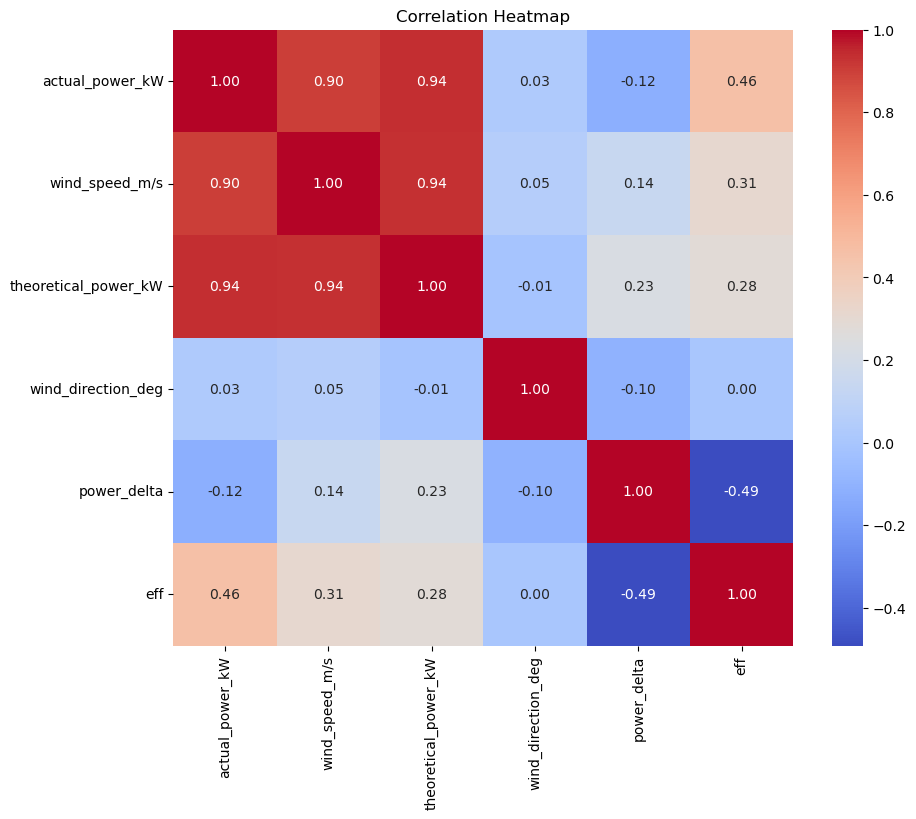

In [57]:
plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')
plt.show()

The strongest correlation observed was between actual_power_kW and theoretical_power_kW (r = 0.95).

The weakest relationship was observed between wind_direction_deg and actual_power_kW (r = 0.03).

This indicates that wind speed and theoretical power are the primary drivers of turbine performance, while wind direction has limited influence on power generation.

In [58]:
corr_matrix.to_csv(
    "../outputs/tables/correlation_matrix.csv"
)

print("Correlation matrix saved.")

Correlation matrix saved.


Covariance Matrix

In [59]:
cov_matrix = df[analysis_cols].cov()

cov_matrix.round(3)

,actual_power_kW,wind_speed_m/s,theoretical_power_kW,wind_direction_deg,power_delta,eff
actual_power_kW,1668976.623,4420.619,1597165.755,3172.348,-71810.869,184.611
wind_speed_m/s,4420.619,14.359,4667.766,16.960,247.147,0.363
theoretical_power_kW,1597165.755,4667.766,1734096.780,-971.302,136931.025,114.772
wind_direction_deg,3172.348,16.960,-971.302,7674.580,-4143.650,0.031
power_delta,-71810.869,247.147,136931.025,-4143.650,208741.894,-69.839
eff,184.611,0.363,114.772,0.031,-69.839,0.097


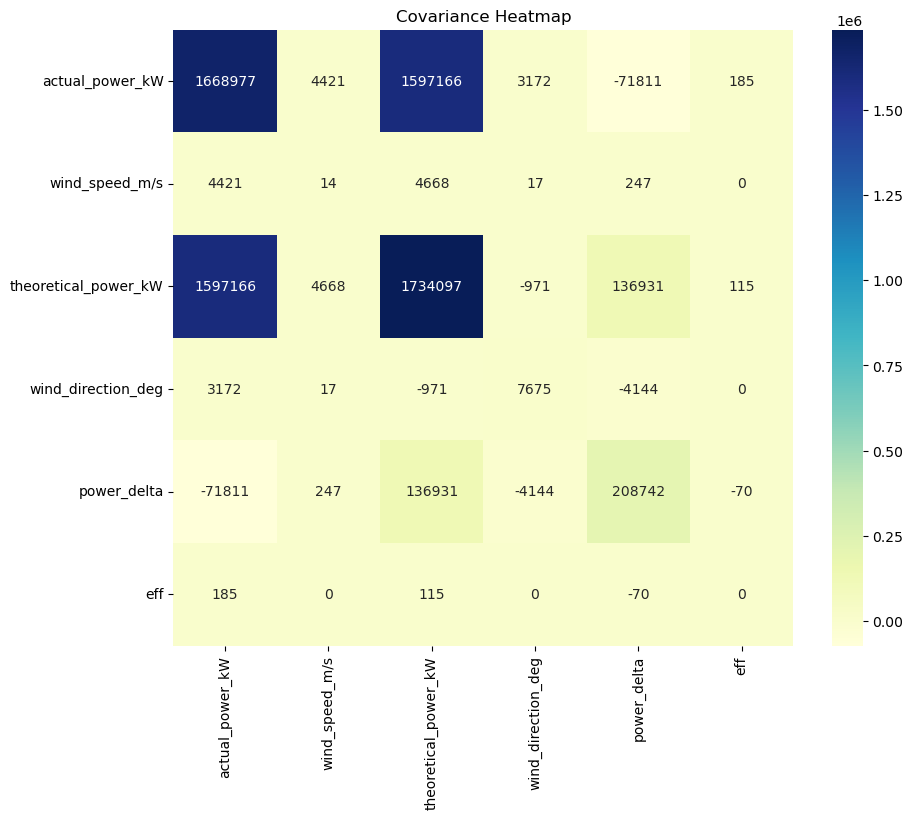

In [60]:
plt.figure(figsize=(10,8))

sns.heatmap(
    cov_matrix,
    annot=True,
    cmap='YlGnBu',
    fmt='.0f'
)

plt.title('Covariance Heatmap')
plt.show()

In [61]:
cov_matrix.to_csv(
    "../outputs/tables/covariance_matrix.csv"
)

print("Covariance matrix saved.")

Covariance matrix saved.


Strongest & Weakest Relationships


In [62]:
corr_pairs = corr_matrix.abs().unstack()

corr_pairs = corr_pairs[
    corr_pairs < 1
]

strongest = corr_pairs.idxmax()
strongest_value = corr_pairs.max()

print("Strongest Relationship:")
print(strongest)
print("Correlation:", round(strongest_value,3))

Strongest Relationship:
('actual_power_kW', 'theoretical_power_kW')
Correlation: 0.939


In [63]:
weakest = corr_pairs.idxmin()
weakest_value = corr_pairs.min()

print("Weakest Relationship:")
print(weakest)
print("Correlation:", round(weakest_value,3))

Weakest Relationship:
('wind_direction_deg', 'eff')
Correlation: 0.001


## Interpretation

1. Actual power output and theoretical power output exhibit the strongest positive relationship.

2. Wind speed shows a strong positive relationship with power generation.

3. Wind direction demonstrates a relatively weak relationship with turbine power output.

4. The results confirm that wind speed is the primary driver of turbine performance.

5. Efficiency is influenced by both theoretical and actual power generation behavior.

In [64]:
df.to_csv(
    "../data/processed/cleaned_scada.csv",
    index=False
)

print("Processed dataset saved successfully.")

Processed dataset saved successfully.
